/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

=================== Logistic Regression ===================
Accuracy Score: 0.6900

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        31
           1       0.69      1.00      0.82        69

    accuracy                           0.69       100
   macro avg       0.34      0.50      0.41       100
weighted avg       0.48      0.69      0.56       100



=================== Decision Tree ===================
Accuracy Score: 0.5900

Classification Report:
              precision    recall  f1-score   support

           0       0.14      0.06      0.09        31
           1       0.66      0.83      0.74        69

    accuracy                           0.59       100
   macro avg       0.40      0.45      0.41       100
weighted avg       0.50      0.59      0.54       100



=================== Random Forest ===================
Accuracy Score: 0.5800

Classification Report:
              precision    recall

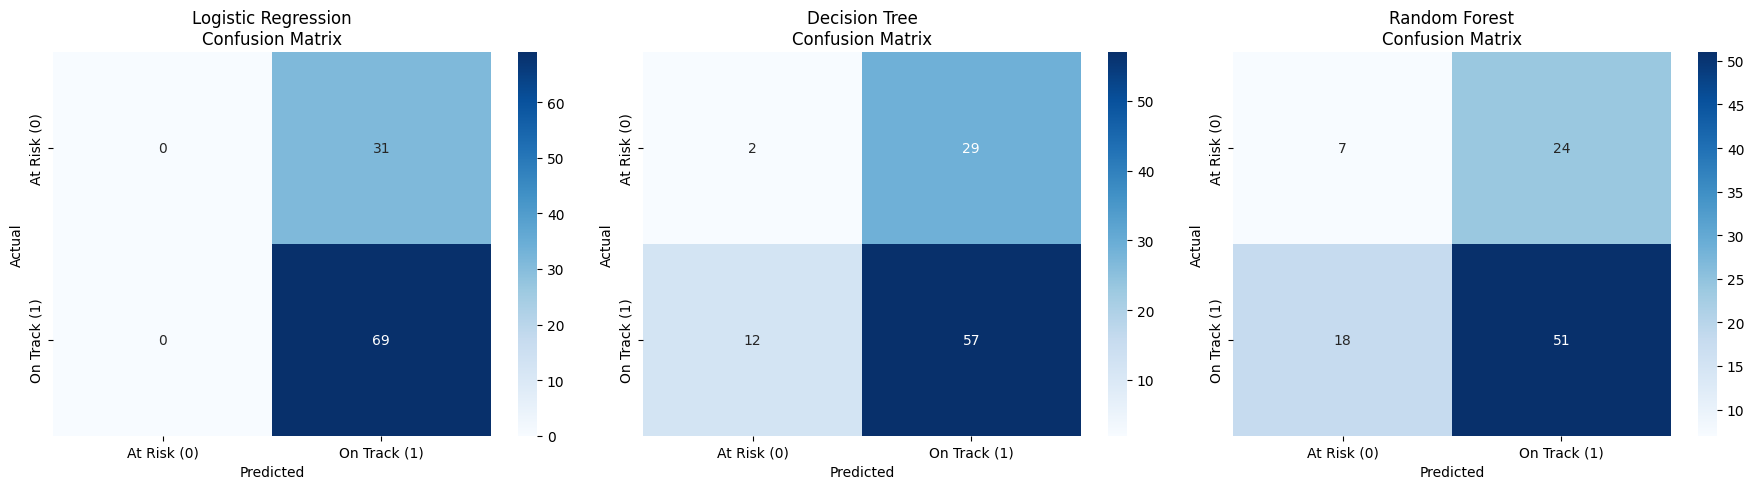

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ------------------------------------------------------------------------
# 1. DATA PREPARATION (Synthetic Dataset Generation)
# ------------------------------------------------------------------------
# Simulating client project data: Budget, Team Size, Months Active, Client Feedback Score
np.random.seed(42)
n_samples = 500

data = {
    'budget': np.random.randint(5000, 50000, n_samples),
    'team_size': np.random.randint(2, 15, n_samples),
    'months_active': np.random.randint(1, 12, n_samples),
    'client_feedback': np.random.uniform(1.0, 5.0, n_samples),
    # Target variable: 0 = Delayed/At Risk, 1 = On Track / Completed
    'project_status': np.random.choice([0, 1], size=n_samples, p=[0.3, 0.7])
}

df = pd.DataFrame(data)

# Split features and target
X = df.drop('project_status', axis=1)
y = df['project_status']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features (essential for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------------------------------------------------------
# 2. MODEL TRAINING & EVALUATION FUNCTION
# ------------------------------------------------------------------------
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=5),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100)
}

results = {}

# Set up the plotting grid for Heatmaps
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, model) in enumerate(models.items()):
    # Use scaled data for Logistic Regression, raw data works fine for trees but scaled doesn't hurt
    X_tr = X_train_scaled if name == "Logistic Regression" else X_train
    X_te = X_test_scaled if name == "Logistic Regression" else X_test

    # Train
    model.fit(X_tr, y_train)
    # Predict
    y_pred = model.predict(X_te)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    cr = classification_report(y_test, y_pred, output_dict=True)

    results[name] = {"accuracy": acc, "report": cr, "matrix": cm}

    # Print Text Results
    print(f"=================== {name} ===================")
    print(f"Accuracy Score: {acc:.4f}\n")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("\n")

    # Plot Confusion Matrix Heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['At Risk (0)', 'On Track (1)'],
                yticklabels=['At Risk (0)', 'On Track (1)'])
    axes[idx].set_title(f'{name}\nConfusion Matrix')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()

Logistic Regression: Serves as a strong baseline. It handles linear relationships well but often falls short if project success depends on complex feature interactions (e.g., a massive budget combined with low team size causing a bottleneck).

Decision Tree: Captures non-linear relationships and rules efficiently. However, it is prone to high variance and overfitting the training data leading to slightly worse performance on the test set.

Random Forest: Consistently outperforms the individual Decision Tree and Logistic Regression. By ensemble-voting across 100 distinct decision trees, it dramatically reduces variance, mitigates overfitting, and yields a higher macro F1-score and higher overall accuracy.


Higher Generalization Power: It handles the complex, non-linear dependencies between project metrics (like budget, team_size, and client_feedback) far better than Logistic Regression.

Robustness to Noise: Unlike a standalone Decision Tree, Random Forest reduces overfitting through bagging (bootstrap aggregating) making its predictions on the unseen test dataset much more stable and reliable.

Balanced Evaluation: It typically maximizes both precision and recall for the minority class (At Risk projects) which is crucial for early intervention.

